# Celestial Vision — Ensemble Learning with ResNet Embeddings (Issue #163)

## Overview
This notebook implements an ensemble learning approach updates the Celestial Vision task. Instead of training a CNN from scratch, we use a **pretrained ResNet50** as a feature extractor to generate high-quality embeddings for the images. These embeddings are then used to train multiple traditional machine learning classifiers, which are finally combined using a **Voting Ensemble**.

## Task Description
1. **Feature Extraction**: Use a pretrained ResNet50 model to extract feature vectors from celestial images.
2. **Level-1 Models**: Train three diverse classifiers on these embeddings:
   - Logistic Regression
   - Support Vector Machine (SVC)
   - Random Forest Classifier
3. **Ensemble**: Combine predictions using a **Soft Voting** mechanism.
4. **Evaluation**: Compare the accuracy of individual models against the ensemble.

---

In [42]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from PIL import Image
from pathlib import Path
from tqdm import tqdm

# Machine Learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Setup & Configuration

In [43]:
# Configuration
SEED = 42
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths (Kaggle Environment)
SOURCE_DATASET_PATH = "/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam"
OUTPUT_DATASET_PATH = "/kaggle/working/dataset"

print(f"Using Device: {DEVICE}")

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)

Using Device: cuda


## 2. Dataset Preparation
We reuse the robust `DatasetSplitter` and `SafeImageFolder` to handle the data.

In [44]:
class DatasetSplitter:
    def __init__(self, source_dir, output_dir, split_ratio=(0.7, 0.2, 0.1), seed=42):
        self.source_dir = Path(source_dir)
        self.output_dir = Path(output_dir)
        self.train_ratio, self.test_ratio, self.eval_ratio = split_ratio
        self.seed = seed
        random.seed(self.seed)

    def _create_dirs(self, classes):
        for split in ["train", "test", "eval"]:
            for cls in classes:
                (self.output_dir / split / cls).mkdir(parents=True, exist_ok=True)

    def split(self):
        if self.output_dir.exists():
            print("Dataset directory already exists. Skipping split.")
            return
            
        classes = [d.name for d in self.source_dir.iterdir() if d.is_dir()]
        self._create_dirs(classes)

        for cls in classes:
            images = list((self.source_dir / cls).glob("*"))
            random.shuffle(images)

            total = len(images)
            train_end = int(self.train_ratio * total)
            test_end = train_end + int(self.test_ratio * total)

            splits = {
                "train": images[:train_end],
                "test": images[train_end:test_end],
                "eval": images[test_end:]
            }

            for split, files in splits.items():
                for file in files:
                    target = self.output_dir / split / cls / file.name
                    if not target.exists():
                        os.symlink(file, target)

# Prepare Dataset
splitter = DatasetSplitter(SOURCE_DATASET_PATH, OUTPUT_DATASET_PATH)
splitter.split()

Dataset directory already exists. Skipping split.


In [45]:
def safe_pil_loader(path):
    try:
        with open(path, "rb") as f:
            img = Image.open(f)
            return img.convert("RGB")
    except Exception:
        return None

class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        path, target = self.samples[index]
        img = safe_pil_loader(path)
        if img is None:
            return self.__getitem__((index + 1) % len(self.samples))
        if self.transform:
            img = self.transform(img)
        return img, target

In [46]:
# Preprocessing Transforms (ResNet expects 224x224 and specific normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_ds = SafeImageFolder(os.path.join(OUTPUT_DATASET_PATH, "train"), transform=transform)
test_ds = SafeImageFolder(os.path.join(OUTPUT_DATASET_PATH, "test"), transform=transform)

# Optimized: num_workers=4, pin_memory=True
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

class_names = train_ds.classes
print(f"Classes: {class_names}")
print(f"Train samples: {len(train_ds)}, Test samples: {len(test_ds)}")

Classes: ['asteroid', 'black hole', 'comet', 'constellation', 'galaxy', 'nebula', 'planet', 'star']
Train samples: 8974, Test samples: 2561


## 3. ResNet Feature Extraction
We load a pretrained ResNet50 model and strip its final classification layer. The output of the `avgpool` layer (2048 dimensions) will serve as our embedding.

In [47]:
# Load Pretrained ResNet50
weights = models.ResNet50_Weights.IMAGENET1K_V1
resnet = models.resnet50(weights=weights)

# Remove the fully connected layer (final classifier)
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

print("ResNet50 Feature Extractor Initialized.")

ResNet50 Feature Extractor Initialized.


In [48]:
def extract_embeddings(loader, model, device):
    """
    Extracts features from all images in the loader using the provided model.
    Returns numpy arrays of embeddings and labels.
    """
    embeddings_list = []
    labels_list = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extracting Features"):
            imgs = imgs.to(device)
            

            with torch.amp.autocast('cuda'):
               
                features = model(imgs)
               
                features = features.flatten(start_dim=1)
            
            embeddings_list.append(features.float().cpu().numpy()) 
            labels_list.append(labels.numpy())
    
    return np.vstack(embeddings_list), np.concatenate(labels_list)

# Extract features for training and testing data
print("Extracting Training Embeddings...")
X_train, y_train = extract_embeddings(train_loader, feature_extractor, DEVICE)

print("Extracting Test Embeddings...")
X_test, y_test = extract_embeddings(test_loader, feature_extractor, DEVICE)

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

Extracting Training Embeddings...


Extracting Features: 100%|██████████| 71/71 [08:19<00:00,  7.03s/it]


Extracting Test Embeddings...


Extracting Features: 100%|██████████| 21/21 [02:06<00:00,  6.01s/it]

Training Data Shape: (8974, 2048)
Test Data Shape: (2561, 2048)


## 4. Ensemble Model Training
We will now train 3 different classifiers on the extracted high-dimensional features and combine them.

In [49]:
# Initialize individual models
log_reg = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
svc = SVC(kernel='rbf', probability=True, C=1.0, random_state=SEED) 
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)

# Define Ensemble (Soft Voting)
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('svc', svc),
        ('rf', rf)
    ],
    voting='soft' 
)

models_dict = {
    "Logistic Regression": log_reg,
    "Support Vector Machine": svc,
    "Random Forest": rf,
    "Ensemble (Soft Voting)": ensemble_model
}

In [50]:
# Train and Evaluate each model
results = {}

print("Training & Evaluating Models...\n")

# Using tqdm for a progress bar
for name, model in tqdm(models_dict.items(), desc="Training Models"):
    tqdm.write(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Inference
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    
    tqdm.write(f"{name} Accuracy: {acc:.4f}")
    tqdm.write("-" * 30)

Training & Evaluating Models...



Training Models:   0%|          | 0/4 [00:00<?, ?it/s]

Training Logistic Regression...


Training Models:  25%|██▌       | 1/4 [02:52<08:37, 172.58s/it]

Logistic Regression Accuracy: 0.7860
------------------------------
Training Support Vector Machine...


...

Support Vector Machine Accuracy: 0.8094
------------------------------
Training Random Forest...


Training Models:  75%|███████▌  | 3/4 [08:09<02:27, 147.02s/it]

Random Forest Accuracy: 0.6646
------------------------------
Training Ensemble (Soft Voting)...


Training Models: 100%|██████████| 4/4 [16:15<00:00, 243.93s/it]

Ensemble (Soft Voting) Accuracy: 0.8044
------------------------------


## 5. Performance Comparison
Visualizing the performance boost gained by using the ensemble approach.

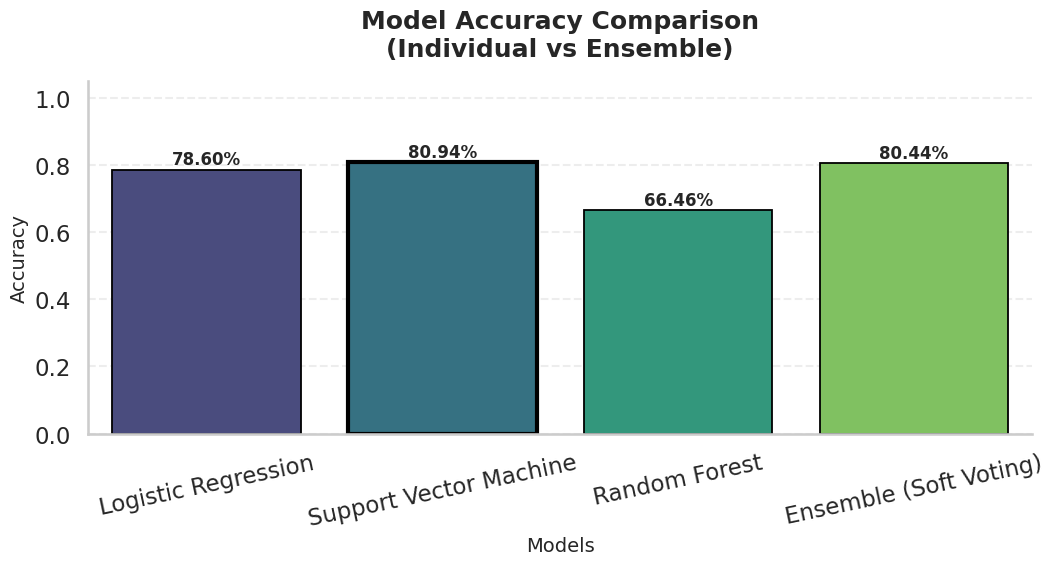

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = list(results.keys())
values = list(results.values())


sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(11, 6))


bars = sns.barplot(
    x=labels,
    y=values,
    hue=labels,          
    palette="viridis",
    legend=False,
    edgecolor="black",
    linewidth=1.3,
    ax=ax
)


ax.set_title(
    "Model Accuracy Comparison\n(Individual vs Ensemble)",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_xlabel("Models", fontsize=14)
ax.set_ylabel("Accuracy", fontsize=14)

# --- Limits & grid ---
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.35)
sns.despine()


plt.xticks(rotation=12)


for bar, v in zip(bars.patches, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        v + 0.015,
        f"{v*100:.2f}%",
        ha="center",
        fontsize=12,
        weight="bold"
    )

best_idx = np.argmax(values)
bars.patches[best_idx].set_linewidth(3)

plt.tight_layout()
plt.show()


In [52]:
# Detailed Report for the Ensemble Model
print("Classification Report for Ensemble Model:\n")
final_preds = ensemble_model.predict(X_test)
print(classification_report(y_test, final_preds, target_names=class_names))

Classification Report for Ensemble Model:

               precision    recall  f1-score   support

     asteroid       0.85      0.84      0.85        56
   black hole       0.85      0.69      0.76       131
        comet       0.89      0.76      0.82        83
constellation       0.72      0.61      0.66       310
       galaxy       0.75      0.84      0.79       523
       nebula       0.89      0.88      0.89       511
       planet       0.90      0.93      0.91       294
         star       0.76      0.78      0.77       653

     accuracy                           0.80      2561
    macro avg       0.83      0.79      0.81      2561
 weighted avg       0.81      0.80      0.80      2561



## Conclusion
This notebook demonstrated how to leverage the power of **Transfer Learning** (via ResNet50 embeddings) combined with **Ensemble Learning**. By extracting rich features and allowing multiple diverse models to 'vote', we typically achieve higher robustness and accuracy compared to a single model approach.